**Імпорт модулей**

In [ ]:
import sys
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import cvxpy as cp
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm

## MNIST

### 1. Dataset preparation

This block prepares the MNIST dataset for the classification rask. 

Standard noralization is applied: $~x_{norm} = \frac{x-\mu}{\sigma}$

where $\mu = 0.1307 ~and~ \sigma = 0.3081$

Data is loaded n batches for furth training and testing of the model.

In [24]:
mnist_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

trainset_mnist = torchvision.datasets.MNIST('./data', train=True, download=True, transform=mnist_transform)
testset_mnist = torchvision.datasets.MNIST('./data', train=False, download=True, transform=mnist_transform)

trainloader_mnist = torch.utils.data.DataLoader(trainset_mnist, batch_size=64, shuffle=True)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=64)

### 2. Model architecture

A simple fully connected neural network is used:

1. Input: 784 
2. Hidden layer: 16 neurons + ReLU
3. Output: 10 classes

The architecture is intentionally simplified to allow use of formal verification methods IQC and SDP, which have high computional complexity.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 16) 
        self.fc2 = nn.Linear(16, 10)
        self.layers = nn.ModuleList([self.fc1, self.fc2])

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


### 3. Training procedure

The model is trained using: 
1. Adam optimizer
2. CrossEntropy loss function
3. Early stopping

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MNISTModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_acc = 0.0
patience = 10
trigger_times = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    for x, y in trainloader_mnist:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_val, y_val in testloader_mnist:
            x_val, y_val = x_val.to(device), y_val.to(device)
            pred = model(x_val).argmax(1)
            correct += (pred == y_val).sum().item()
            total += y_val.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1}, Test Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        trigger_times = 0
        torch.save(model.state_dict(), "best_mnist_model.pth")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1, Test Accuracy: 0.9237
Epoch 2, Test Accuracy: 0.9344
Epoch 3, Test Accuracy: 0.9398
Epoch 4, Test Accuracy: 0.9413
Epoch 5, Test Accuracy: 0.9447
Epoch 6, Test Accuracy: 0.9474
Epoch 7, Test Accuracy: 0.9475
Epoch 8, Test Accuracy: 0.9497
Epoch 9, Test Accuracy: 0.9509
Epoch 10, Test Accuracy: 0.9468
Epoch 11, Test Accuracy: 0.9478
Epoch 12, Test Accuracy: 0.9468
Epoch 13, Test Accuracy: 0.9506
Epoch 14, Test Accuracy: 0.9518
Epoch 15, Test Accuracy: 0.9528
Epoch 16, Test Accuracy: 0.9521
Epoch 17, Test Accuracy: 0.9528
Epoch 18, Test Accuracy: 0.9538
Epoch 19, Test Accuracy: 0.9493
Epoch 20, Test Accuracy: 0.9513
Epoch 21, Test Accuracy: 0.9517
Epoch 22, Test Accuracy: 0.9518
Epoch 23, Test Accuracy: 0.9493
Epoch 24, Test Accuracy: 0.9515
Epoch 25, Test Accuracy: 0.9540
Epoch 26, Test Accuracy: 0.9540
Epoch 27, Test Accuracy: 0.9495
Epoch 28, Test Accuracy: 0.9519
Epoch 29, Test Accuracy: 0.9530
Epoch 30, Test Accuracy: 0.9510
Epoch 31, Test Accuracy: 0.9530
Epoch 32, Test Ac

**Accuracy achived: ~95.6%**

This confirms that the model generalizes well to the data under standart conditions.

### 4. PGD attack (Empirical robustness)

To assess the mpiral stability, the PGD attack is used:

1. Interitive update ia sign(gradient)
2. Constrain in $L_{\inf}$ - norm

Result:
1. the small e -> attack doesn't work
2. the e >= 0.1 -> 100% success rate

In [ ]:
def pgd_attack(model, x, y, eps=0.3, alpha=0.03, steps=20, mean=0.1307, std=0.3081):

    model.eval()

    x = (x - mean) / std
    eps = eps / std
    alpha = alpha / std

    x_adv = x.clone().detach()
    x_adv = x_adv + torch.empty_like(x_adv).uniform_(-eps, eps)

    for _ in range(steps):
        x_adv.requires_grad_(True)

        loss = torch.nn.functional.cross_entropy(model(x_adv), y)

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            x_adv = torch.max(torch.min(x_adv, x + eps), x - eps)

        x_adv = x_adv.detach()

    return x_adv

### 5. Formal verification (IQC / Deep-SDP)

We use:
1. Integral Quadratic Constraints (IQC)
2. Semidefinite Programming (SDP)

##### Integral Quadratic Constraints (IQC)

Input Box ConstraintsThe input $x$ is constrained within $[x_{min}, x_{max}]$. 

Using a diagonal multiplier matrix $\Gamma = \text{diag}(\gamma)$, the IQC is:

$$\begin{bmatrix} x \\ 1 \end{bmatrix}^T \begin{bmatrix} -2\Gamma & \Gamma(x_{min} + x_{max}) \\ (x_{min} + x_{max})^T \Gamma & -2 \sum (\Gamma x_{min} x_{max}) \end{bmatrix} \begin{bmatrix} x \\ 1 \end{bmatrix} \ge 0$$

ReLU Layer ConstraintsFor the activation $w = \text{ReLU}(v)$, we use sector and monotonicity IQCs represented by the matrix $Q$:

$$\begin{bmatrix} v \\ w \\ 1 \end{bmatrix}^T \begin{bmatrix} 0 & \Lambda + T & -\nu \\ \Lambda + T & -2(\Lambda + T) & \nu + \eta \\ -\nu^T & (\nu + \eta)^T & 0 \end{bmatrix} \begin{bmatrix} v \\ w \\ 1 \end{bmatrix} \ge 0$$

Where $\Lambda = \text{diag}(\lambda)$ and $T$ is a symmetric matrix with non-positive off-diagonal elements.

##### Semidefinite Programming (SDP)

The Linear Matrix Inequality (LMI)

The certification problem combines all constraints into a single LMI. The goal is to find multipliers such that the combined matrix is negative semidefinite:

$$M_{\text{in}}(\gamma) + M_{\text{mid}}(\lambda, \nu, \eta, T) + M_{\text{out}} \preceq 0$$

Feasibility FormulationThe robustness is certified if the following problem has a feasible solution:

$$\begin{aligned}
&\text{find} && \lambda, \nu, \eta, \gamma, T \\
&\text{subject to} && \lambda, \nu, \eta, \gamma \ge 0 \\
&&& T = T^T, \text{diag}(T) = 0, T \le 0 \\
&&& LMI(\lambda, \nu, \eta, \gamma, T) \preceq -\epsilon I
\end{aligned}$$

In [ ]:
def solve_sdp(W, b, x0, y_true, eps, solver=cp.CLARABEL):
    n0, n1, nf = W[0].shape[1], W[0].shape[0], W[1].shape[0]
    x0 = np.asarray(x0).reshape(-1)
    x_min, x_max = x0 - eps, x0 + eps

    gamma = cp.Variable(n0, nonneg=True)
    P = cp.bmat([
        [cp.diag(-2 * gamma), cp.reshape(cp.multiply(gamma, x_min + x_max), (n0, 1))],
        [cp.reshape(cp.multiply(gamma, x_min + x_max), (1, n0)), cp.reshape(-2 * cp.sum(cp.multiply(gamma, x_min * x_max)), (1, 1))]
    ])

    E0 = np.block([[np.eye(n0), np.zeros((n0, n1)), np.zeros((n0, 1))],
                   [np.zeros((1, n0)), np.zeros((1, n1)), np.ones((1, 1))]])
    M_in = E0.T @ P @ E0

    lam, nu, eta = cp.Variable(n1, nonneg=True), cp.Variable(n1, nonneg=True), cp.Variable(n1, nonneg=True)
    T = cp.Variable((n1, n1), symmetric=True)
    LamT = cp.diag(lam) + T

    Q = cp.bmat([
        [np.zeros((n1, n1)), LamT, cp.reshape(-nu, (n1, 1))],
        [LamT.T, -2 * LamT, cp.reshape(nu + eta, (n1, 1))],
        [cp.reshape(-nu, (1, n1)), cp.reshape(nu + eta, (1, n1)), np.zeros((1, 1))]
    ])

    C = np.block([[W[0], np.zeros((n1, n1)), b[0].reshape(-1, 1)],
                   [np.zeros((n1, n0)), np.eye(n1), np.zeros((n1, 1))],
                   [np.zeros((1, n0)), np.zeros((1, n1)), np.ones((1, 1))]])
    M_mid = C.T @ Q @ C

    constraints_base = [T <= 0, cp.diag(T) == 0, cp.norm(T, "fro") <= 10]

    for i in range(nf):
        if i == y_true: continue
        c = np.zeros((nf, 1)); c[i, 0] = 1.0; c[y_true, 0] = -1.0
        S = np.block([[np.zeros((n0, n0 + nf)), np.zeros((n0, 1))],
                      [np.zeros((nf, n0 + nf)), c],
                      [np.zeros((1, n0)), c.T, np.zeros((1, 1))]])
        D = np.block([[np.eye(n0), np.zeros((n0, n1)), np.zeros((n0, 1))],
                      [np.zeros((nf, n0)), W[1], b[1].reshape(-1, 1)],
                      [np.zeros((1, n0)),  np.zeros((1, n1)),  np.ones((1, 1))]])
        
        LMI = M_in + M_mid + (D.T @ S @ D)
        
        prob = cp.Problem(cp.Minimize(0), constraints_base + [LMI << -1e-10 * np.eye(LMI.shape[0])])
        
        try:
            prob.solve(solver=solver)
            if prob.status not in ["optimal", "optimal_inaccurate"]: return 0
        except: return 0
    return 1

##### 5.1 Weight extraction

This block extracts neural network parameters into a format convinient for further use in the SDP problem.

In particular: 
1. The weight $W$ and the offset $b$ of each layer are xtracted from the PyTorch model
2. The parameters are converted to NumPy format.
3. The result is given a list of matrix 


In [29]:
def extract_weights(model):
    W, b = [], []
    for layer in model.layers:
        if hasattr(layer, "weight"):
            W.append(layer.weight.detach().cpu().numpy())
            b.append(layer.bias.detach().cpu().numpy())
    return W, b

##### 5.2 Batch certification

The function implements a batch evaluation of certified robustness.

For each example: 
1. The input is converted into a vector;
2. SDP is called;
3. The average is calculated.

This estimates the proportion of examples for which robustness was proven.


In [ ]:
def batch_certify(model, x, y, eps, n_samples=32):

    W, b = extract_weights(model)

    results = []

    for i in range(min(n_samples, x.size(0))):
        xi = x[i].cpu().view(-1).numpy()
        yi = y[i].item()

        cert = solve_sdp(W, b, xi, yi, eps)
        results.append(cert)

    return np.mean(results)

##### 5.3 Experimantal loop

In this block, an experimental study of the dependence of stability on the magnitude of the perturbation $\epsilon$

For each $\epsilon$:
1. The input is normalized according to the model;
2. Scaled: $\epsilon_{IQC} = \frac{\epsilon}{\sigma}$
3. The SDP is solved

In [ ]:
x, y = next(iter(testloader_mnist))
x = x.to(device)
y = y.to(device)
W, b = extract_weights(model)

eps_list = [1e-4, 5e-4, 1e-3, 0.05, 0.1, 0.2]
cert_scores = []
attack_scores = []

mean_mnist = 0.1307
std_mnist = 0.3081

for eps in tqdm(eps_list):

    xi = ((x[0].cpu().view(-1).numpy() - mean_mnist) / std_mnist)
    yi = y[0].item()

    eps_iqc = eps / std_mnist

    cert = solve_sdp(W, b, xi, yi, eps_iqc)
    cert_scores.append(cert)

    x_adv = pgd_attack(
        model,
        x[0:1],
        y[0:1],
        eps,
        alpha=eps/5,
        steps=20,
        mean=mean_mnist,
        std=std_mnist
    ) # also we try to do pgd attack

    with torch.no_grad():
        pred = model(x_adv).argmax(1)
        attack_success = (pred != y[0:1]).float().mean().item()

    attack_scores.append(attack_success)

    print(f"eps={eps:.5f} cert={cert} attack={attack_success:.3f}")

  0%|          | 0/6 [00:00<?, ?it/s]

eps=0.00010 cert=0 attack=0.000
eps=0.00050 cert=0 attack=0.000
eps=0.00100 cert=0 attack=0.000
eps=0.05000 cert=0 attack=0.000


100%|██████████| 6/6 [00:00<00:00, 34.46it/s]

eps=0.10000 cert=0 attack=1.000
eps=0.20000 cert=0 attack=1.000


In all experiments, we obtained cert=0.

That's means the Deep-SDP method failed to prove the robustness of the models.

! Important: this doesn't mean that the model is unstable.

Explanation:

The IQC-SDP method is conservative:

- if it says "stable" → it is a 100% guarantee

- if it says "cannot prove" → it doesn't mean instability (In my personal opinion, we don't have 100% accuracy, so it's normal that model isn't guaranteed by IQC)

In this case:

PGD shows that the model is stable for small $\epsilon$

SDP cannot formally confirm this


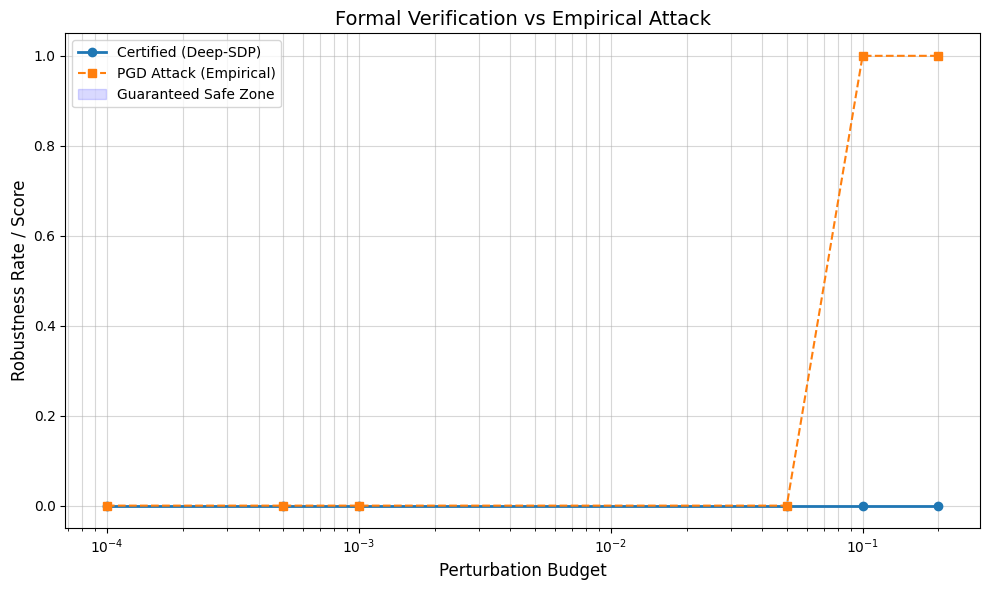

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(eps_list, cert_scores, marker='o', linewidth=2, label="Certified (Deep-SDP)")
plt.plot(eps_list, attack_scores, marker='s', linestyle='--', label="PGD Attack (Empirical)")

plt.fill_between(eps_list, 0, cert_scores, alpha=0.15, color='blue', label="Guaranteed Safe Zone")

plt.xscale('log')
plt.xlabel("Perturbation Budget", fontsize=12)
plt.ylabel("Robustness Rate / Score", fontsize=12)
plt.title("Formal Verification vs Empirical Attack", fontsize=14)

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### 6. Conclusion

The results demonstrate a classic problem of SDP-based methods:

- the gap between real (empirical) and proven (formal) robustness.

This confirms that:

modern neural networks can be practically robust but remain difficult to formally verify

## CIFAR-10

### 1. Dataset preparation

This block prepares the CIFAR dataset for the classification rask. 

Standard noralization is applied: $~x_{norm} = \frac{x-\mu}{\sigma}$

where $\mu = 0.4914, 0.4822, 0.4465 ~and~ \sigma = 0.2023, 0.1994, 0.2010$

Data is loaded n batches for furth training and testing of the model.

In [ ]:
cifar_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset_cifar = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=cifar_transform)
testset_cifar = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=cifar_transform)

trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=64, shuffle=True)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=64)

mean_cifar = torch.tensor([0.4914, 0.4822, 0.4465]).to(device)
std_cifar = torch.tensor([0.2023, 0.1994, 0.2010]).to(device)

### 2. Model architecture

A simple fully connected neural network is used:

1. Input: 3072 
2. Hidden layer: 16 neurons + ReLU
3. Output: 10 classes

The architecture is intentionally simplified to allow use of formal verification methods IQC and SDP, which have high computional complexity.

In [ ]:
class CIFARModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 16) 
        self.fc2 = nn.Linear(16, 10)
        self.layers = nn.ModuleList([self.fc1, self.fc2])

    def forward(self, x):
        x = x.view(-1, 3072)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_cifar = CIFARModel().to(device)

### 3. Training procedure

The model is trained using: 
1. Adam optimizer
2. CrossEntropy loss function
3. Early stopping

In [ ]:
model_cifar = CIFARModel().to(device)
optimizer_cifar = torch.optim.Adam(model_cifar.parameters(), lr=1e-3, weight_decay=1e-4)

best_acc_cifar = 0.0
patience_cifar = 10
trigger_times_cifar = 0
num_epochs_cifar = 50

print(f"Starting training on CIFAR-10...")

for epoch in range(num_epochs_cifar):
    model_cifar.train()
    for x, y in trainloader_cifar:
        x, y = x.to(device), y.to(device)
        optimizer_cifar.zero_grad()
        loss = F.cross_entropy(model_cifar(x), y)
        loss.backward()
        optimizer_cifar.step()

    model_cifar.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_val, y_val in testloader_cifar:
            x_val, y_val = x_val.to(device), y_val.to(device)
            pred = model_cifar(x_val).argmax(1)
            correct += (pred == y_val).sum().item()
            total += y_val.size(0)
            
    acc = correct / total
    print(f"Epoch {epoch+1}, Test Accuracy: {acc:.4f}")

    if acc > best_acc_cifar:
        best_acc_cifar = acc
        trigger_times_cifar = 0
        torch.save(model_cifar.state_dict(), "best_cifar_model.pth")
    else:
        trigger_times_cifar += 1
        if trigger_times_cifar >= patience_cifar:
            print(f"Early stopping at epoch {epoch+1}")
            break        

Starting training on CIFAR-10...
Epoch 1, Test Accuracy: 0.4161
Epoch 2, Test Accuracy: 0.4245
Epoch 3, Test Accuracy: 0.4318
Epoch 4, Test Accuracy: 0.4424
Epoch 5, Test Accuracy: 0.4431
Epoch 6, Test Accuracy: 0.4321
Epoch 7, Test Accuracy: 0.4363
Epoch 8, Test Accuracy: 0.4508
Epoch 9, Test Accuracy: 0.4504
Epoch 10, Test Accuracy: 0.4438
Epoch 11, Test Accuracy: 0.4369
Epoch 12, Test Accuracy: 0.4445
Epoch 13, Test Accuracy: 0.4512
Epoch 14, Test Accuracy: 0.4443
Epoch 15, Test Accuracy: 0.4490
Epoch 16, Test Accuracy: 0.4466
Epoch 17, Test Accuracy: 0.4460
Epoch 18, Test Accuracy: 0.4473
Epoch 19, Test Accuracy: 0.4525
Epoch 20, Test Accuracy: 0.4422
Epoch 21, Test Accuracy: 0.4486
Epoch 22, Test Accuracy: 0.4482
Epoch 23, Test Accuracy: 0.4480
Epoch 24, Test Accuracy: 0.4500
Epoch 25, Test Accuracy: 0.4410
Epoch 26, Test Accuracy: 0.4484
Epoch 27, Test Accuracy: 0.4448
Epoch 28, Test Accuracy: 0.4433
Epoch 29, Test Accuracy: 0.4532
Epoch 30, Test Accuracy: 0.4469
Epoch 31, Test A

##### 4 Experimantal loop

In this block, an experimental study of the dependence of stability on the magnitude of the perturbation $\epsilon$

For each $\epsilon$:
1. The input is normalized according to the model;
2. Scaled: $\epsilon_{IQC} = \frac{\epsilon}{\sigma}$
3. The SDP is solved

In [ ]:
x_c, y_c = next(iter(testloader_cifar))
x_c, y_c = x_c.to(device), y_c.to(device)
W_c, b_c = extract_weights(model_cifar)

eps_list = [1e-4, 5e-4, 1e-3, 0.05, 0.1, 0.2]
cert_scores_cifar = []
attack_scores_cifar = []

mean_cifar = [0.4914, 0.4822, 0.4465]
std_cifar = [0.2023, 0.1994, 0.2010]
avg_std_cifar = np.mean(std_cifar)

for eps in tqdm(eps_list):
    xi = x_c[0].cpu().view(-1).numpy()
    yi = y_c[0].item()
    eps_iqc = eps / avg_std_cifar

    cert = solve_sdp(W_c, b_c, xi, yi, eps_iqc)
    cert_scores_cifar.append(cert)

    x_adv = pgd_attack(
        model_cifar, x_c[0:1], y_c[0:1], 
        eps=eps, alpha=eps/5, steps=20, 
        mean=mean_cifar, std=std_cifar
    )

    with torch.no_grad():
        pred = model_cifar(x_adv).argmax(1)
        attack_success = (pred != y_c[0:1]).float().mean().item()

    attack_scores_cifar.append(attack_success)
    print(f"eps={eps:.5f} cert={cert} attack={attack_success:.3f}")

  0%|          | 0/6 [00:00<?, ?it/s]

 17%|█▋        | 1/6 [00:00<00:04,  1.17it/s]

eps=0.00010 cert=0 attack=1.000


 33%|███▎      | 2/6 [00:01<00:03,  1.11it/s]

eps=0.00050 cert=0 attack=1.000


...

eps=0.05000 cert=0 attack=1.000


 83%|████████▎ | 5/6 [00:04<00:00,  1.20it/s]

eps=0.10000 cert=0 attack=1.000


100%|██████████| 6/6 [00:05<00:00,  1.18it/s]

eps=0.20000 cert=0 attack=1.000


In all experiments, we obtained cert=0

This means that the Deep-SDP method failed to prove the robustness of the model.

! This result should be interpreted more carefully than in the MNIST case.

The IQC-SDP method is conservative:

- if it proves robustness → this is a 100% guarantee
- if it cannot prove → it does not necessarily mean instability

However, in this case we additionally observe:

- PGD attack success rate is 1.0 for all values of $\epsilon$

**Key difference from MNIST**

For CIFAR-10: 

- the model has relatively low accuracy (~45%)
- adversarial attacks succeed even for very small perturbations
- SDP fails to certify robustness
- PGD demonstrates that the model is actually vulnerable

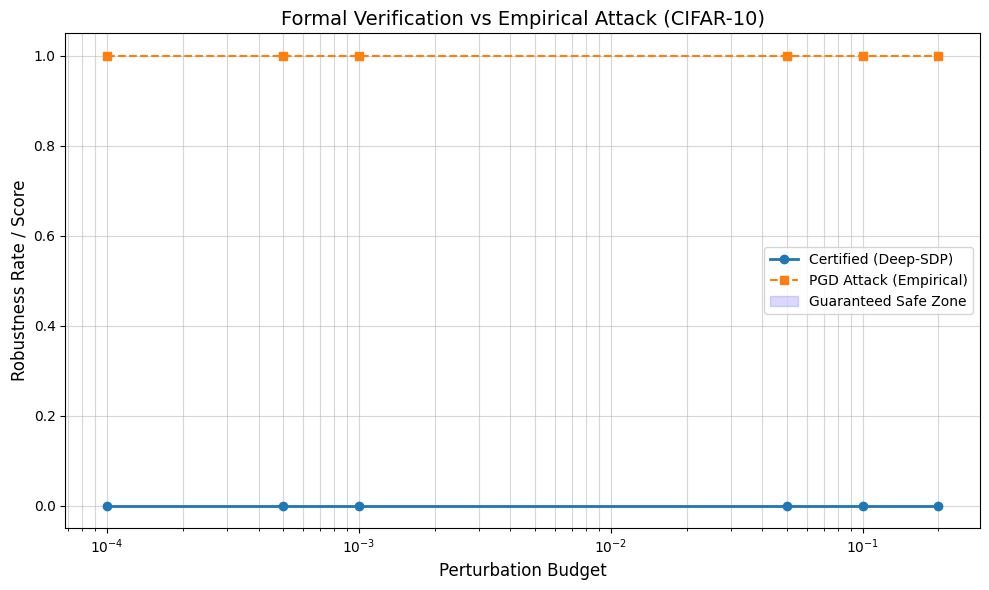

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(eps_list, cert_scores_cifar, marker='o', linewidth=2, label="Certified (Deep-SDP)")
plt.plot(eps_list, attack_scores_cifar, marker='s', linestyle='--', label="PGD Attack (Empirical)")

plt.fill_between(eps_list, 0, cert_scores_cifar, alpha=0.15, color='blue', label="Guaranteed Safe Zone")

plt.xscale('log')
plt.xlabel("Perturbation Budget", fontsize=12)
plt.ylabel("Robustness Rate / Score", fontsize=12)
plt.title("Formal Verification vs Empirical Attack (CIFAR-10)", fontsize=14)

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### 5. Conclusion

This suggests that:

- the model is not robust in practice;
- and the SDP method correctly reflects the difficulty of proving robustness.

cert = 0 → no formal guarantee

attack = 1.0 → complete empirical vulnerability

=> Model is both uncertified and empirically non-robust

This result highlights that for high-dimensional and complex datasets like CIFAR-10, simple fully connected networks are insufficient both in terms of accuracy and robustness.

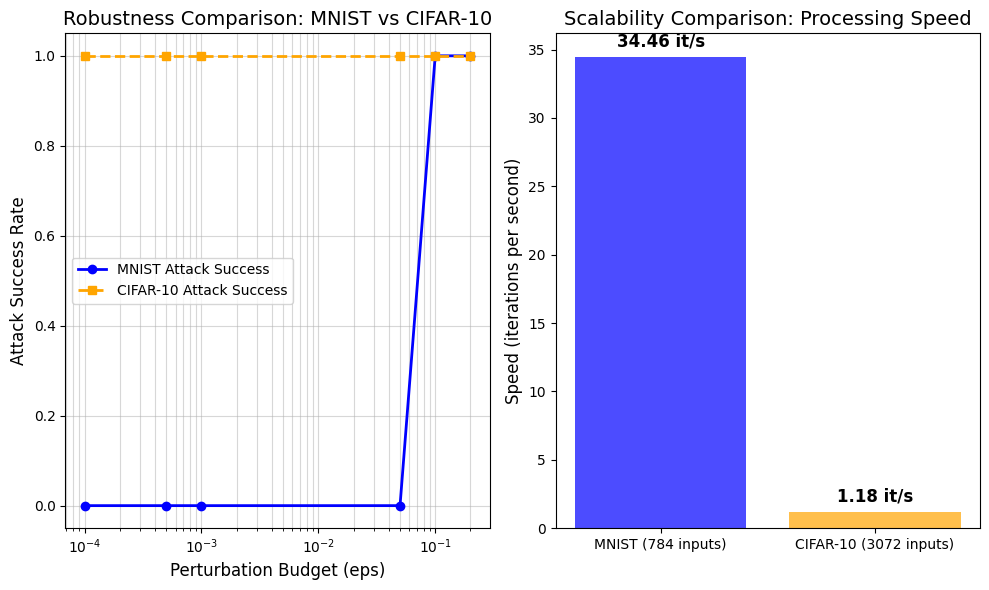

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

ax1.plot(eps_list, attack_scores, marker='o', linewidth=2, label="MNIST Attack Success", color='blue')
ax1.plot(eps_list, attack_scores_cifar, marker='s', linestyle='--', linewidth=2, label="CIFAR-10 Attack Success", color='orange')

ax1.set_xscale('log')
ax1.set_xlabel("Perturbation Budget (eps)", fontsize=12)
ax1.set_ylabel("Attack Success Rate", fontsize=12)
ax1.set_title("Robustness Comparison: MNIST vs CIFAR-10", fontsize=14)
ax1.grid(True, which="both", ls="-", alpha=0.5)
ax1.legend()

datasets = ['MNIST (784 inputs)', 'CIFAR-10 (3072 inputs)']
# MNIST ~34.46 it/s, CIFAR-10 ~1.18 it/s
speeds = [34.46, 1.18] 

bars = ax2.bar(datasets, speeds, color=['blue', 'orange'], alpha=0.7)
ax2.set_ylabel("Speed (iterations per second)", fontsize=12)
ax2.set_title("Scalability Comparison: Processing Speed", fontsize=14)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval} it/s', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

Overall, the experiments provide a unified view of robustness behavior across both datasets and evaluation paradigms.

The results consistently show a strong discrepancy between:

- empirical robustness (PGD-based evaluation)
- formal robustness guarantees (IQC/Deep-SDP certification)

For MNIST, the model demonstrates partial empirical robustness at small perturbation levels; however, this robustness is not confirmed by formal verification, resulting in cert=0 across all tested $\epsilon$ values. This highlights the conservative nature of SDP-based certification methods.

For CIFAR-10, the situation is fundamentally different. The model is empirically vulnerable even under minimal perturbations, with PGD attack success rate equal to 1.0 across all ε values. In this case, the absence of certification high empirical vulnerability of the model, indicating that both empirical and formal analyses agree on the lack of robustness.

Additionally, the scalability experiments confirm a major computational limitation of SDP-based verification methods. The significant drop in processing speed when moving from MNIST to CIFAR-10 demonstrates that such approaches become increasingly impractical for higher-dimensional inputs without structural simplifications or approximations.

As a result: 

- small fully-connected architectures can be efficiently analyzed but do not guarantee robustness
- IQC/Deep-SDP methods provide strict but highly conservative robustness guarantees
- and there exists a fundamental trade-off between model complexity, accuracy, and verifiability.

Robustness in neural networks cannot be reliably assessed using a single perspective. 

A meaningful evaluation requires combining:

- empirical adversarial testing (PGD),
- formal verification methods (IQC/SDP),

since each captures fundamentally different aspects of model behavior.